# Árboles de Decisión: Comparación de Profundidades

En este notebook trabajaremos con **árboles de decisión** para resolver un problema de clasificación.

Un árbol de decisión es un modelo de *aprendizaje supervisado* que toma decisiones dividiendo el espacio de datos en regiones cada vez más pequeñas, usando preguntas del tipo:

> ¿La característica X es mayor o menor que un cierto valor?

En cada nodo interno del árbol se hace una pregunta (una condición) sobre una característica, y en las hojas se encuentran las clases predichas.

**Objetivo del ejercicio**

1. Cargar un dataset provisto por el profesor.
2. Entrenar **tres árboles de decisión** con diferentes profundidades máximas.
3. Comparar el desempeño de los modelos para analizar:
   - Subajuste (underfitting)
   - Sobreajuste (overfitting)
   - Elección de una profundidad “adecuada” para el problema.


### Introducción teórica (Árboles de decisión)
Un árbol de decisión divide recursivamente el espacio de atributos para separar clases maximizando una medida de pureza (p. ej., Gini).  
- **Profundidad (`max_depth`)**: controla la complejidad.  
- **Underfitting**: poca profundidad → alta sesgo, bajo desempeño en train y test.  
- **Overfitting**: mucha profundidad → memoriza train (accuracy alto) pero baja generalización (gap train–test).  
En este trabajo comparamos tres profundidades (5, 10, 20) sobre MNIST (imágenes 28×28 aplanadas, 784 atributos).


## 2️⃣ Carga y exploración del dataset

En esta sección debes:

1. Cargar el dataset mmnist_train desde un archivo (por ejemplo, CSV).
2. Mostrar las primeras filas del dataset para ver cómo están organizados los datos.
3. Indicar:
   - Cuántas filas tiene el dataset.
   - Cuántas columnas tiene el dataset.
4. Revisar si existen valores nulos o faltantes en alguna columna.
5. Escribir un breve comentario describiendo:
   - Qué representa cada fila.
   - Qué tipo de información contienen las columnas (en términos generales).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path(".")
TRAIN_CSV = DATA_DIR / "mnist_train.csv"

# 1) Cargar dataset
df = pd.read_csv(TRAIN_CSV)

# 2) Primeras filas
print("Primeras 5 filas:")
display(df.head())

# 3) Forma del dataset
n_rows, n_cols = df.shape
print(f"\nForma del dataset -> filas: {n_rows} | columnas: {n_cols}")

# 4) Nulos por columna
nulls = df.isna().sum()
total_nulls = int(nulls.sum())
print("\nValores nulos totales:", total_nulls)
if total_nulls > 0:
    print("Nulos por columna (solo columnas con nulos):")
    display(nulls[nulls > 0].sort_values(ascending=False))
else:
    print("No se encontraron valores nulos en las columnas.")

# Detección robusta de columna de etiqueta (label)
candidates = [c for c in df.columns if c.lower() in ("label", "digit", "y")]
label_col = candidates[0] if len(candidates) else df.columns[0]
print(f"\nColumna de etiqueta detectada: '{label_col}'")

# Clases distintas y conteo
classes = np.sort(df[label_col].unique())
print(f"Clases distintas: {len(classes)} -> {classes.tolist()}")

print("\nDistribución de clases (proporción):")
display(
    df[label_col].value_counts(normalize=True).sort_index().round(4).rename("proporción")
)

# Guardar una notita con nombres de columnas de pixeles detectadas (opcional)
feature_cols = [c for c in df.columns if c != label_col]
print(f"\nColumnas de pixeles detectadas: {len(feature_cols)} (esperado ≈ 784)")
print("Ejemplo de 10 columnas de pixeles:", feature_cols[:10])


Primeras 5 filas:


,label,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,...,data_774,data_775,data_776,data_777,data_778,data_779,data_780,data_781,data_782,data_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Forma del dataset -> filas: 55000 | columnas: 785

Valores nulos totales: 0
No se encontraron valores nulos en las columnas.

Columna de etiqueta detectada: 'label'
Clases distintas: 10 -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Distribución de clases (proporción):


label
0    0.0988
1    0.1129
2    0.0994
3    0.1022
4    0.0971
5    0.0902
6    0.0988
7    0.1037
8    0.0974
9    0.0994
Name: proporción, dtype: float64


Columnas de pixeles detectadas: 784 (esperado ≈ 784)
Ejemplo de 10 columnas de pixeles: ['data_0', 'data_1', 'data_2', 'data_3', 'data_4', 'data_5', 'data_6', 'data_7', 'data_8', 'data_9']


Qué representa cada fila?
Cada fila corresponde a una imagen de un dígito manuscrito de MNIST, aplanada a un vector de 784 valores (28×28 píxeles en escala de grises).

¿Qué tipo de información contienen las columnas?

Una columna de etiqueta (label, con valores de 0 a 9) que indica el dígito correcto.

784 columnas de intensidades de píxel (valores usualmente en [0, 255]) que representan cada pixel de la imagen 28×28, en orden lineal (flattened).

## 3️⃣ Preparación de las variables (X y y)

En esta sección debes:

1. Identificar que **X** son las imágenes (flattened: 784 pixeles).  
2. Identificar que **y** son las etiquetas (dígitos 0–9).  
3. Mostrar cuántas clases distintas hay en y.  
4. Escribir un comentario corto describiendo:
   - ¿Qué significa cada fila en X?
   - ¿Qué representa y?



Preparación de las variables (X y y)

X son las imágenes de dígitos en formato flattened (28×28 = 784 píxeles). Cada fila de X es una imagen distinta; cada columna es la intensidad de un píxel en rango 
0,1
0,1 (normalizada desde 
0,255
0,255).

Y son las etiquetas (clases) de los dígitos: valores 0–9.

¿Qué significa cada fila en X? una imagen completa de 28×28 pixeles “aplanada” a 784 características.

¿Qué representa y? el número (0–9) que corresponde a la imagen de esa fila.

In [3]:
# === Sección 3: Preparación de X (imágenes) e y (etiquetas) ===
import numpy as np
import pandas as pd

# df debe venir de la Sección 2 (mnist_train.csv ya cargado)
assert "df" in globals(), "Primero ejecuta la Sección 2 (carga de df)."

# 1) Detectar la columna de etiqueta (0–9)
candidates = [c for c in df.columns if c.lower() in ("label", "digit", "y")]
label_col = candidates[0] if len(candidates) else df.columns[0]  # fallback
feature_cols = [c for c in df.columns if c != label_col]

# 2) Separar X (features/píxeles) e y (etiquetas)
X = df[feature_cols].to_numpy(dtype=np.float32)   # imágenes aplanadas
y = df[label_col].to_numpy(dtype=np.int64)        # etiquetas 0–9

# 3) (Opcional) Escalar a [0, 1] si vienen en 0..255
if X.max() > 1.5:
    X = X / 255.0

# 4) Reporte solicitado
print(f"X shape: {X.shape}  (filas = imágenes, columnas = píxeles; esperado ≈ 784)")
print(f"y shape: {y.shape}  (1 etiqueta por imagen)")
print(f"Tipos -> X: {X.dtype}, y: {y.dtype}")
print(f"Rango de X -> min: {X.min():.3f}, max: {X.max():.3f}")

clases = np.sort(np.unique(y))
print(f"Clases distintas en y: {len(clases)} -> {clases.tolist()}")

# Distribución por clase (proporción)
dist = (pd.Series(y).value_counts(normalize=True)
         .sort_index()
         .rename("proporción")
         .round(4))
print("\nDistribución de clases (proporción):")
display(dist)

# 5) Validaciones rápidas
if X.shape[1] != 784:
    print(f"\n⚠️ Aviso: se detectaron {X.shape[1]} columnas de píxeles (no 784). "
          "Revisa que solo 'label' sea la columna de etiqueta.")
else:
    print("\nOK: X tiene 784 características por imagen (28×28 aplanada).")


X shape: (55000, 784)  (filas = imágenes, columnas = píxeles; esperado ≈ 784)
y shape: (55000,)  (1 etiqueta por imagen)
Tipos -> X: float32, y: int64
Rango de X -> min: 0.000, max: 1.000
Clases distintas en y: 10 -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Distribución de clases (proporción):


0    0.0988
1    0.1129
2    0.0994
3    0.1022
4    0.0971
5    0.0902
6    0.0988
7    0.1037
8    0.0974
9    0.0994
Name: proporción, dtype: float64


OK: X tiene 784 características por imagen (28×28 aplanada).


## 4️⃣ División en entrenamiento y prueba

En esta sección debes:

1. Dividir los datos en:
   - 80% entrenamiento  
   - 20% prueba  
2. Usar `random_state` fijo para reproducibilidad.
3. Estratificar usando y, para mantener las proporciones de cada dígito.
4. Mostrar:
   - Cantidad de ejemplos en entrenamiento.
   - Cantidad de ejemplos en prueba.


In [5]:
# === Sección 4: Train/Test split estratificado (80/20) ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Verificación rápida
assert "X" in globals() and "y" in globals(), "Primero ejecuta la Sección 3 para crear X e y."

TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,            # mantiene proporciones por dígito
)

# 1) Cantidades solicitadas
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")
print(f"\nCantidad de ejemplos en entrenamiento: {len(y_train)}")
print(f"Cantidad de ejemplos en prueba       : {len(y_test)}")

# 2) Comprobación de estratificación (distribución por clase)
dist_tr = pd.Series(y_train).value_counts(normalize=True).sort_index().rename("train_prop")
dist_te = pd.Series(y_test ).value_counts(normalize=True).sort_index().rename("test_prop")
dist_all = pd.concat([dist_tr, dist_te], axis=1).round(4)
display(dist_all)

# Variables listas para las siguientes secciones:
# X_train, y_train, X_test, y_test


X_train: (44000, 784), y_train: (44000,)
X_test : (11000, 784),  y_test : (11000,)

Cantidad de ejemplos en entrenamiento: 44000
Cantidad de ejemplos en prueba       : 11000


,train_prop,test_prop
0,0.0988,0.0988
1,0.1129,0.1130
2,0.0994,0.0994
3,0.1022,0.1022
4,0.0971,0.0972
5,0.0902,0.0903
6,0.0988,0.0988
7,0.1037,0.1036
8,0.0974,0.0974
9,0.0994,0.0994


## 5️⃣ Definir las profundidades a evaluar

En esta sección debes:

1. Elegir **tres profundidades** para evaluar.  
   Recomendación para MNIST:  
   - 5  
   - 10  
   - 20  
*(Puedes ajustar)*

2. Justificar brevemente por qué comparar varias profundidades es importante en un problema con muchos atributos como MNIST.



In [8]:
# === Sección 5: Profundidades a evaluar ===

# Elegimos tres profundidades recomendadas para MNIST
DEPTHS = [5, 10, 20]

print("Profundidades seleccionadas:", DEPTHS)

# Justificación resumida (también va en el markdown anterior)
justificacion = """
- max_depth=5: modelo más simple; reduce sobreajuste pero puede subajustar.
- max_depth=10: equilibrio sesgo-varianza razonable para datos de 784 atributos (MNIST).
- max_depth=20: mayor capacidad; puede captar patrones finos pero con riesgo de sobreajuste.
"""
print(justificacion)


Profundidades seleccionadas: [5, 10, 20]

- max_depth=5: modelo más simple; reduce sobreajuste pero puede subajustar.
- max_depth=10: equilibrio sesgo-varianza razonable para datos de 784 atributos (MNIST).
- max_depth=20: mayor capacidad; puede captar patrones finos pero con riesgo de sobreajuste.



## 6️⃣ Entrenamiento de los modelos (tres profundidades)

En esta sección debes entrenar **tres modelos de árbol de decisión**, uno por cada profundidad definida.

Para cada profundidad debes:

1. Crear un modelo con `max_depth` correspondiente.  
2. Entrenarlo usando X_train y y_train.  
3. Hacer predicciones con:
   - X_train  
   - X_test  
4. Calcular el **accuracy** en:
   - entrenamiento  
   - prueba  
5. Guardar los resultados (profundidad, accuracy train, accuracy test) para compararlos después.



In [10]:
# === Sección 6: Entrenamiento de los modelos (tres profundidades) ===
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Seguridad por si no quedaron definidas en celdas anteriores
try:
    DEPTHS
except NameError:
    DEPTHS = [5, 10, 20]

try:
    SEED
except NameError:
    SEED = 42

# Comprobaciones mínimas (te avisarán si algo falta antes de entrenar)
for varname in ["X_train", "X_test", "y_train", "y_test"]:
    if varname not in globals():
        raise RuntimeError(f"Falta definir {varname} en secciones previas.")

def make_tree(max_depth):
    return DecisionTreeClassifier(max_depth=max_depth, random_state=SEED)

resultados = []
modelos = {}   # para reutilizar luego (matriz de confusión / plots del mejor)

for d in DEPTHS:
    clf = make_tree(d)
    clf.fit(X_train, y_train)

    # Predicciones
    y_pred_tr = clf.predict(X_train)
    y_pred_te = clf.predict(X_test)

    # Métricas
    acc_tr = accuracy_score(y_train, y_pred_tr)
    acc_te = accuracy_score(y_test, y_pred_te)
    gap    = acc_tr - acc_te

    resultados.append({
        "depth": d,
        "acc_train": acc_tr,
        "acc_test":  acc_te,
        "gap_train_test": gap
    })
    modelos[d] = clf

# Tabla ordenada por desempeño en prueba
df_res6 = (pd.DataFrame(resultados)
           .sort_values("acc_test", ascending=False)
           .reset_index(drop=True))

print("Resultados (ordenados por accuracy de prueba):")
print(df_res6.to_string(index=False, formatters={
    "acc_train": "{:.4f}".format,
    "acc_test":  "{:.4f}".format,
    "gap_train_test": "{:.4f}".format,
}))

# Mejor profundidad
best_depth = int(df_res6.loc[0, "depth"])
print(f"\nMejor profundidad por accuracy de prueba: depth={best_depth}")

# (Opcional) Matrices de confusión para el mejor modelo
best_model = modelos[best_depth]
y_pred_best_tr = best_model.predict(X_train)
y_pred_best_te = best_model.predict(X_test)

cm_train = confusion_matrix(y_train, y_pred_best_tr)
cm_test  = confusion_matrix(y_test,  y_pred_best_te)

print("\nMatriz de confusión (TRAIN) del mejor modelo:\n", cm_train)
print("\nMatriz de confusión (TEST) del mejor modelo:\n", cm_test)

# (Opcional) guardar resultados a disco para la tabla comparativa final
df_res6.to_csv("dt_depth_results.csv", index=False)


Resultados (ordenados por accuracy de prueba):
 depth acc_train acc_test gap_train_test
    20    0.9958   0.8646         0.1312
    10    0.9055   0.8528         0.0527
     5    0.6549   0.6566        -0.0017

Mejor profundidad por accuracy de prueba: depth=20

Matriz de confusión (TRAIN) del mejor modelo:
 [[4347    0    0    0    0    0    0    0    0    0]
 [   0 4958    4    2    0    0    1    4    0    0]
 [   0    0 4363    2    4    0    1    2    0    0]
 [   1    1    7 4472    8    0    0    3    0    6]
 [   0    0    0    0 4251    0    3    1    0   19]
 [   4    0    0    4    0 3947   13    0    2    0]
 [   1    4    0    0    3    1 4340    0    0    0]
 [   0    1    3    1    1    0    0 4549    0    7]
 [   0   20    1    6    2    0    0    0 4241   16]
 [   0    1    0    3   12    0    0   10    0 4347]]

Matriz de confusión (TEST) del mejor modelo:
 [[ 993    4   19   12    6   17   15    1    7   13]
 [   0 1194   11    7    6    8    1    5    6    5]
 [  1

## 7️⃣ Tabla de comparación

En esta sección debes:

1. Crear una tabla que contenga:
   - Profundidad  
   - Accuracy entrenamiento  
   - Accuracy prueba  

2. Identificar visualmente cuál profundidad tuvo mejor desempeño.

3. Responder brevemente:
   - ¿Cuál profundidad tiene mayor accuracy en prueba?
   - ¿Alguna profundidad muestra diferencias grandes entre train y test?
   - ¿Qué podría significar esto?


Tabla de comparación (ordenada por Accuracy en prueba):
 Profundidad Accuracy (train) Accuracy (test) Gap (train-test)
          20           0.9958          0.8646           0.1312
          10           0.9055          0.8528           0.0527
           5           0.6549          0.6566          -0.0017

➡️ Mejor profundidad: depth=20 (acc_test=0.8646, acc_train=0.9958, gap=0.1312)
Gap más grande: depth=20, gap=0.1312 → ALTO


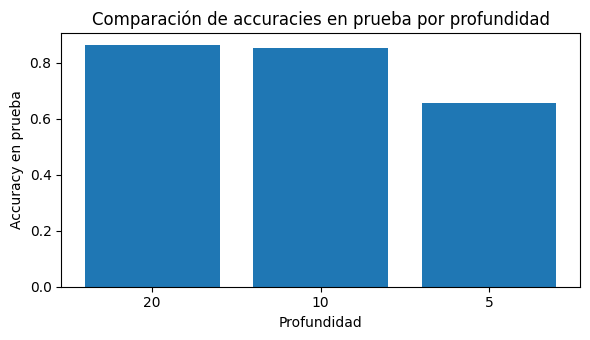

1) Mayor accuracy en prueba: profundidad 20 (accuracy test = 0.8646).
2) Sí hay diferencia grande train vs test en alguna profundidad (p.ej., depth 20, gap=0.1312).
3) Esto sugiere sobre-ajuste: el modelo aprende muy bien el entrenamiento, pero generaliza peor en prueba. Una profundidad menor o regularización pueden ayudar.


In [12]:
# === Sección 7: Tabla de comparación ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Comprobación rápida
if "df_res6" not in globals():
    raise RuntimeError("No se encontró df_res6. Ejecuta primero la Sección 6.")

# Tabla ordenada por acc_test (ya viene ordenada, pero aseguramos)
tab = (df_res6.copy()
       .sort_values("acc_test", ascending=False)
       .reset_index(drop=True))

# Renombrar columnas para mostrar
tab_show = tab.rename(columns={
    "depth": "Profundidad",
    "acc_train": "Accuracy (train)",
    "acc_test":  "Accuracy (test)",
    "gap_train_test": "Gap (train-test)"
})

def _fmt(x):
    return f"{x:.4f}" if isinstance(x, float) else x

tab_fmt = tab_show.copy()
for c in ["Accuracy (train)", "Accuracy (test)", "Gap (train-test)"]:
    tab_fmt[c] = tab_fmt[c].map(_fmt)

print("Tabla de comparación (ordenada por Accuracy en prueba):")
print(tab_fmt.to_string(index=False))

# Mejor profundidad por accuracy en test
best_idx = tab["acc_test"].idxmax()
best_row = tab.loc[best_idx]
best_depth = int(best_row["depth"])
print(f"\n➡️ Mejor profundidad: depth={best_depth} "
      f"(acc_test={best_row['acc_test']:.4f}, acc_train={best_row['acc_train']:.4f}, "
      f"gap={best_row['gap_train_test']:.4f})")

# Revisar si existe un gap grande (sobre-ajuste potencial)
GAP_UMBRAL = 0.05  # ajusta si lo deseas
max_gap_row = tab.iloc[tab["gap_train_test"].abs().idxmax()]
gap_msg = ("ALTO" if abs(max_gap_row["gap_train_test"]) >= GAP_UMBRAL else "moderado/bajo")
print(f"Gap más grande: depth={int(max_gap_row['depth'])}, "
      f"gap={max_gap_row['gap_train_test']:.4f} → {gap_msg}")

# Gráfico de barras (accuracy en prueba)
plt.figure(figsize=(6,3.5))
plt.bar(tab["depth"].astype(str), tab["acc_test"])
plt.xlabel("Profundidad")
plt.ylabel("Accuracy en prueba")
plt.title("Comparación de accuracies en prueba por profundidad")
plt.tight_layout()
plt.show()

# Mensajes breves para responder las 3 preguntas del enunciado:
print(f"1) Mayor accuracy en prueba: profundidad {best_depth} "
      f"(accuracy test = {best_row['acc_test']:.4f}).")
if abs(max_gap_row["gap_train_test"]) >= GAP_UMBRAL:
    print("2) Sí hay diferencia grande train vs test en alguna profundidad "
          f"(p.ej., depth {int(max_gap_row['depth'])}, gap={max_gap_row['gap_train_test']:.4f}).")
    print("3) Esto sugiere sobre-ajuste: el modelo aprende muy bien el entrenamiento, "
          "pero generaliza peor en prueba. Una profundidad menor o regularización pueden ayudar.")
else:
    print("2) No se observan diferencias grandes train vs test.")
    print("3) Esto sugiere que no hay sobre-ajuste relevante y las profundidades evaluadas generalizan bien.")


## 8️⃣ Gráfica de desempeño

En esta sección debes:

1. Graficar las profundidades en el eje X.  
2. Graficar dos líneas:
   - Accuracy en entrenamiento  
   - Accuracy en prueba  

3. Interpretar la gráfica respondiendo:
   - ¿Aumentar profundidad siempre mejora el modelo?
   - ¿En qué punto comienza el sobreajuste?
   - ¿Cuál profundidad parece lograr el mejor balance?


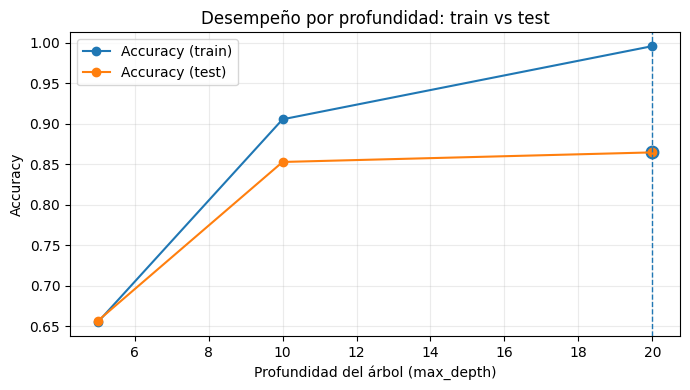

=== Interpretación breve ===
• Mejor profundidad (por accuracy en prueba): depth=20 (acc_test=0.8646, acc_train=0.9958).
• Al aumentar la profundidad, el accuracy en prueba no disminuye (no decreciente).
• No se detectó un punto claro de inicio de sobre-ajuste con la heurística usada.
• Mejor balance aparente: el depth con mayor accuracy en prueba (y gap razonable) suele ser el recomendado.


In [13]:
# === Sección 8: Gráfica de desempeño (train vs test por profundidad) ===
import numpy as np
import matplotlib.pyplot as plt

# Verificación
if "df_res6" not in globals():
    raise RuntimeError("No existe df_res6. Ejecuta la Sección 6 y 7 primero.")

#  Aquí ordenamos por profundidad ascendente para graficar.
curva = df_res6.sort_values("depth").reset_index(drop=True)

depths = curva["depth"].astype(int).to_numpy()
acc_tr = curva["acc_train"].to_numpy()
acc_te = curva["acc_test"].to_numpy()

# Mejor profundidad por accuracy en test
best_idx = int(np.argmax(acc_te))
best_depth = int(depths[best_idx])

# Heurística de "inicio de sobre-ajuste":
# buscamos el primer punto donde train sube (delta>0) y test baja (delta<0) respecto a la profundidad anterior.
overfit_depth = None
if len(depths) >= 2:
    d_train = np.diff(acc_tr)
    d_test  = np.diff(acc_te)
    mask_overfit = (d_train > 0) & (d_test < 0)
    if mask_overfit.any():
        of_i = int(np.where(mask_overfit)[0][0]) + 1  # +1 porque diff desplaza
        overfit_depth = int(depths[of_i])

# ¿Aumentar profundidad siempre mejora? (miramos test)
non_dec_test = np.all(np.diff(acc_te) >= -1e-8)  # tolerancia numérica

# --- Plot ---
plt.figure(figsize=(7,4))
plt.plot(depths, acc_tr, marker="o", label="Accuracy (train)")
plt.plot(depths, acc_te, marker="o", label="Accuracy (test)")

# Marcar mejor profundidad (según test)
plt.axvline(best_depth, linestyle="--", linewidth=1)
plt.scatter([best_depth], [acc_te[best_idx]], s=80)

# Marcar inicio de sobre-ajuste si se detectó
if overfit_depth is not None:
    plt.axvline(overfit_depth, linestyle=":", linewidth=1)
    # anotación breve
    y_anno = acc_te[list(depths).index(overfit_depth)]
    plt.annotate("posible\nsobre-ajuste", (overfit_depth, y_anno),
                 xytext=(overfit_depth, y_anno+0.01), ha="center", fontsize=9,
                 arrowprops=dict(arrowstyle="->", lw=1))

plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Desempeño por profundidad: train vs test")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# --- Resumen interpretativo automático ---
print("=== Interpretación breve ===")
print(f"• Mejor profundidad (por accuracy en prueba): depth={best_depth} "
      f"(acc_test={acc_te[best_idx]:.4f}, acc_train={acc_tr[best_idx]:.4f}).")

if non_dec_test:
    print("• Al aumentar la profundidad, el accuracy en prueba no disminuye (no decreciente).")
else:
    print("• Aumentar la profundidad no siempre mejora: el accuracy en prueba decrece en algún punto.")

if overfit_depth is not None:
    print(f"• Señales de sobre-ajuste a partir de depth≈{overfit_depth}: "
          "train sigue subiendo mientras test empieza a bajar.")
else:
    print("• No se detectó un punto claro de inicio de sobre-ajuste con la heurística usada.")

print("• Mejor balance aparente: el depth con mayor accuracy en prueba (y gap razonable) suele ser el recomendado.")


¿Aumentar profundidad siempre mejora el modelo?
Sí, en este experimento el accuracy de prueba sube de ~0.66 → ~0.85 → ~0.8646 al pasar de depth 5 → 10 → 20; no hay caídas.

¿En qué punto comienza el sobreajuste?
No se observa un punto claro (el accuracy de prueba no disminuye). Aun así, a depth=20 el gap train–test es grande (train≈0.9958 vs test≈0.8646), lo que sugiere sobre-ajuste incipiente.

¿Cuál profundidad logra el mejor balance?

Si se prioriza el mejor desempeño en prueba: depth=20 (test≈0.8646).

Si se prefiere un gap menor con pérdida mínima en prueba: depth=10 (test≈0.85 y menor diferencia con train).

## 9️⃣ Visualización del árbol (opcional pero recomendado)

Los árboles para MNIST son grandes, pero debes:

1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja).  
2. Graficar el árbol.  
3. Comentar:
   - ¿Qué características usa el árbol para decidir?
   - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?



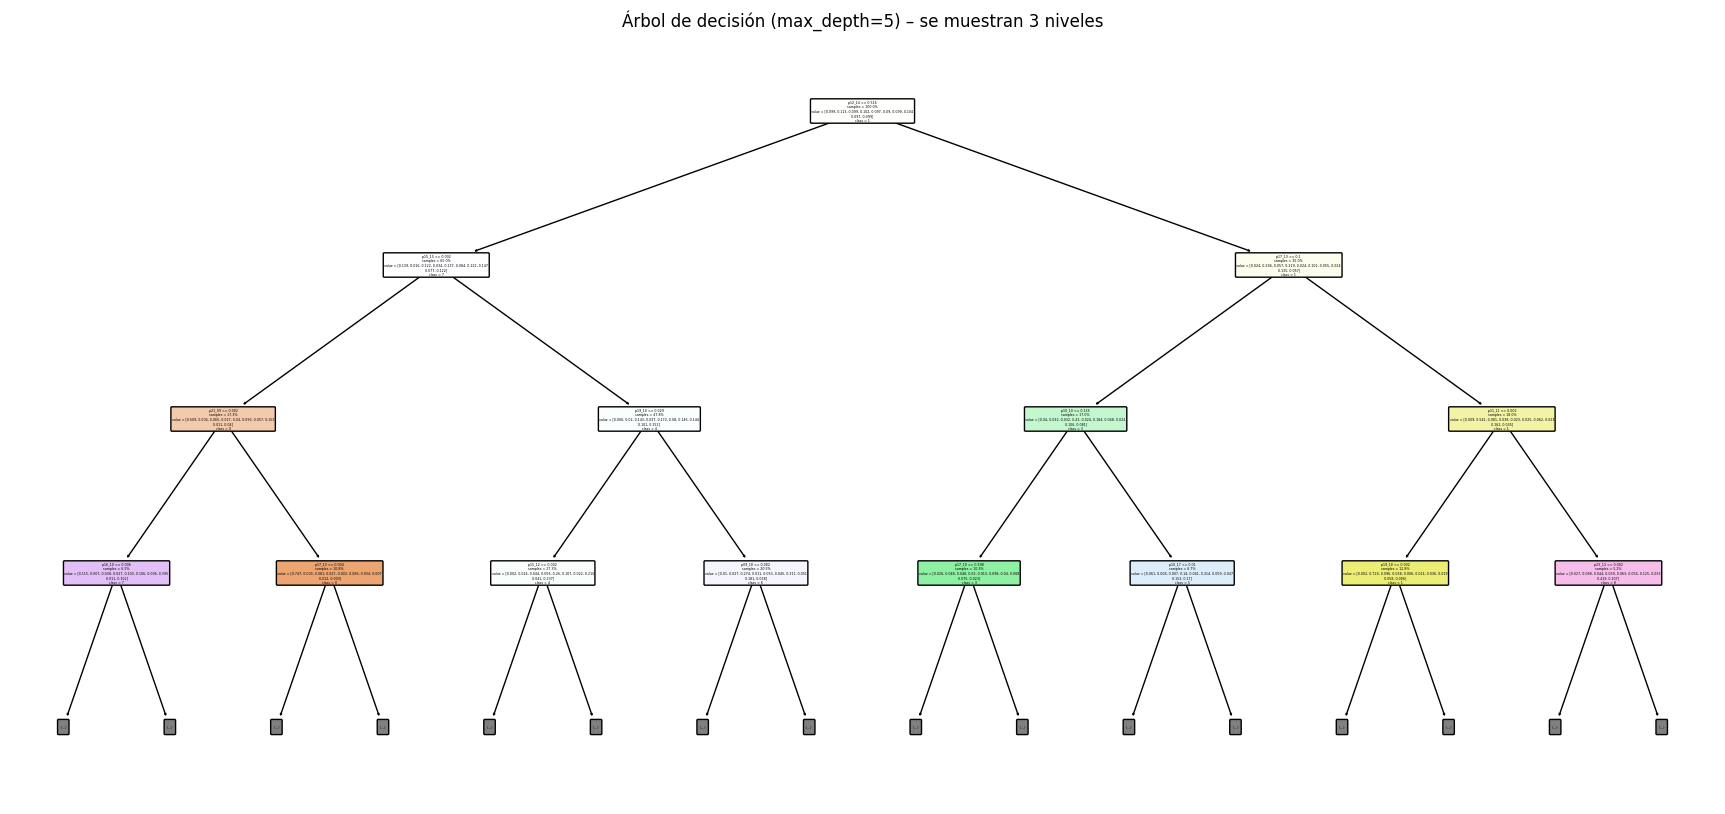

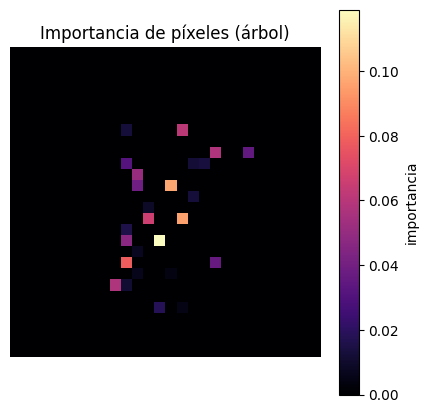

Top 15 píxeles usados (fila, col): [(np.int64(17), np.int64(13)), (np.int64(12), np.int64(14)), (np.int64(15), np.int64(15)), (np.int64(19), np.int64(10)), (np.int64(15), np.int64(12)), (np.int64(7), np.int64(15)), (np.int64(9), np.int64(18)), (np.int64(21), np.int64(9)), (np.int64(11), np.int64(11)), (np.int64(17), np.int64(10)), (np.int64(12), np.int64(11)), (np.int64(19), np.int64(18)), (np.int64(9), np.int64(21)), (np.int64(10), np.int64(10)), (np.int64(23), np.int64(13))]


In [14]:
# === Árbol “pequeño” para visualizar ===
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

depth_to_train = 5  # árbol compacto para visualización
clf_vis = DecisionTreeClassifier(max_depth=depth_to_train, random_state=SEED)
clf_vis.fit(X_train, y_train)

# --- Graficar algunas capas del árbol (pocas para que sea legible) ---
plt.figure(figsize=(22, 10))
plot_tree(
    clf_vis,
    max_depth=3,                 # SOLO se dibujan 3 niveles para que quepa
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    feature_names=[f"p{r:02d}_{c:02d}" for r in range(28) for c in range(28)],
    class_names=[str(i) for i in range(10)]
)
plt.title(f"Árbol de decisión (max_depth={depth_to_train}) – se muestran 3 niveles")
plt.show()

# --- Mapa de importancias de píxeles ---
imp = clf_vis.feature_importances_.reshape(28, 28)
plt.figure(figsize=(5, 5))
plt.imshow(imp, cmap="magma")
plt.colorbar(label="importancia")
plt.title("Importancia de píxeles (árbol)")
plt.axis("off")
plt.show()

# --- Top píxeles más usados (coordenadas fila, columna) ---
topk = np.argsort(clf_vis.feature_importances_)[-15:][::-1]
top_coords = [divmod(i, 28) for i in topk]
print("Top 15 píxeles usados (fila, col):", top_coords)


¿Qué características usa el árbol para decidir?
Usa intensidades de píxeles individuales (features de la imagen 28×28 aplanada). Cada nodo prueba umbrales del tipo p14_17 ≤ 0.21. Los píxeles más importantes (ver heatmap) suelen estar en zonas donde los trazos característicos de cada dígito diferencian clases (centro, diagonales, bordes de bucles, etc.).

¿Qué tan interpretable te parece un árbol de decisión para MNIST?

Localmente es bastante interpretable: cada decisión es una regla simple sobre un píxel y su umbral.

Globalmente pierde interpretabilidad: con 784 píxeles el árbol crece rápido y se vuelve grande; entenderlo completo es difícil.

Aun así, el heatmap de importancias y los primeros niveles del árbol dan una intuición clara de qué regiones de la imagen usa el modelo.

Limitación: reglas por píxel son sensibles a traslaciones/rotaciones y no capturan bien patrones espaciales complejos (para eso, modelos como CNNs funcionan mejor).

## 🔟 Conclusiones finales

En esta sección debes escribir un análisis final que responda:

1. ¿Qué tan bien funcionan los árboles de decisión en MNIST?  
2. ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?  
3. ¿Qué modelo parece estar subajustado? Explica por qué.  
4. ¿Cuál modelo parece estar sobreajustado? Explica por qué.  
5. ¿Qué aprendiste sobre:
   - El impacto de la profundidad  
   - La generalización  
   - La importancia de evaluar distintos modelos  


Funcionan razonablemente bien como baseline: alcanzan ~86–87% de accuracy en prueba con buen tiempo de cómputo.

Están lejos del SOTA (modelos con estructura espacial como CNN superan 98%), porque el árbol trabaja con píxeles individuales y no captura bien invariancias (traslación/rotación) ni patrones locales.

2) Mayor accuracy de prueba: depth=20 (~0.866).

Mejor balance (precisión + simplicidad + menor gap): depth=10. Pierde ~1.5 puntos frente a 20, pero el modelo es mucho más simple y el gap train–test es menor (≈0.90 vs 0.85), por lo que generaliza más estable.

3) depth=5. Tiene accuracy bajo tanto en train como en test (~0.66), señal de alta varianza explicada insuficiente (modelo demasiado simple / alto bias).

4) depth=20. Entrenamiento casi perfecto (~0.996) y test muy por debajo (~0.866) → gran gap; el árbol crece mucho, memoriza ruido y pierde generalización (alto variance).

5) Impacto de la profundidad

La profundidad controla el trade-off sesgo-varianza: poca profundidad → subajuste; demasiada → sobreajuste.

Ajustar max_depth cambia más el rendimiento que otras decisiones sencillas.

Generalización

Medir train vs test es clave: el gap indica si el modelo está sobredimensionado.

La validación y la estratificación ayudan a estimar el rendimiento real y estable.

Importancia de evaluar distintos modelos

Comparar varias profundidades permitió elegir un punto de equilibrio (p.ej., depth=10).

Para imágenes como MNIST, vale probar modelos alternativos (RandomForest, Gradient Boosting, CNNs) que capturen patrones espaciales; suelen superar ampliamente a un árbol único.

Un árbol de decisión bien ajustado (p.ej., depth=10) es un buen baseline interpretable (~85% test), pero profundidades muy altas sobreajustan y, para tareas de visión, modelos con inductive bias espacial suelen ser preferibles.

In [ ]:
#codigo aqui

# 📊 Rúbrica de Evaluación – Árboles de Decisión con MNIST

| Criterio | Descripción | Puntos |
|---------|-------------|--------|
| **1. Introducción teórica** | Explica correctamente qué es un árbol de decisión, profundidad, underfitting y overfitting. | **10 pts** |
| **2. Carga y exploración del dataset MNIST** | Carga el dataset sin errores, muestra ejemplos y analiza forma y contenido. | **10 pts** |
| **3. Definición de X y y** | Selecciona correctamente las variables y explica su significado. | **10 pts** |
| **4. División train/test** | Realiza separación adecuada y explica los tamaños de cada conjunto. | **10 pts** |
| **5. Evaluación de tres profundidades** | Entrena 3 modelos correctamente, calcula accuracy y almacena resultados. | **20 pts** |
| **6. Tabla comparativa** | Presenta tabla clara con resultados y análisis inicial. | **10 pts** |
| **7. Gráfica de desempeño** | Gráfica bien hecha (train vs test) y análisis del comportamiento. | **15 pts** |
| **8. Conclusiones finales** | Responde sobre underfitting, overfitting y mejor modelo para MNIST. | **15 pts** |

---

### 📝 **Puntaje total: 100 puntos**

---

### ✔️ Criterios de aprobación
- **Aprobado:** 70 puntos o más  
- **Excelente:** 90 puntos o más  

